# FedAvg vs FedVARP

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc

import os

## With fine-tuning

In [2]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["42", "78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu-10ft gp-50-tcsu-10ft gp-35-tusu-10ft gp-50-tusu-10ft gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

folder='figures/lr_exp/quanti_analysis/with_ft'
keyword = 'with ft'

Processing experiments:   0%|          | 0/5 [00:00<?, ?it/s]2024-11-07 12:01:06.972506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-07 12:01:06.984617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-07 12:01:06.999426: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-07 12:01:07.003760: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-07

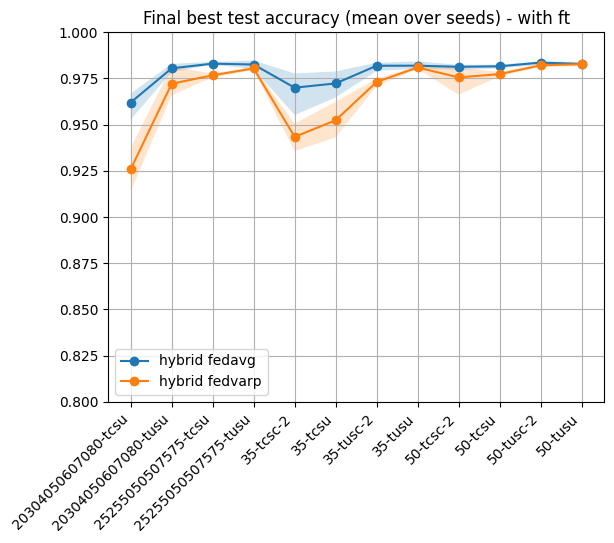

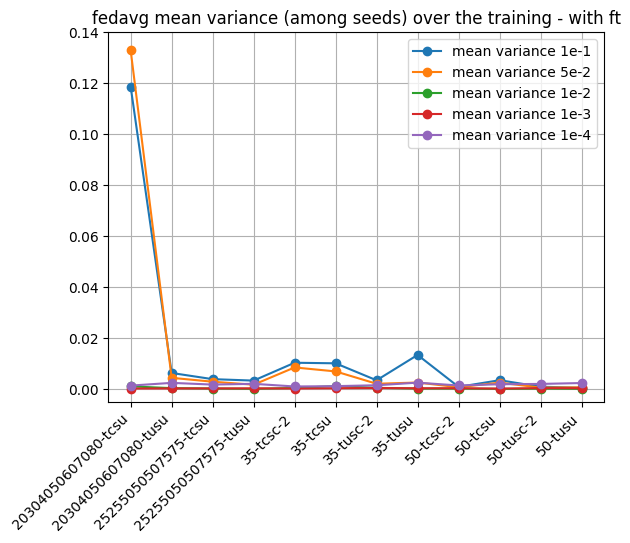

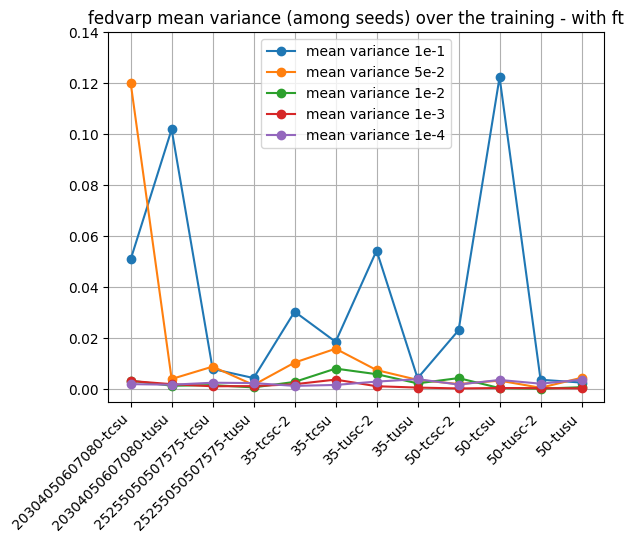

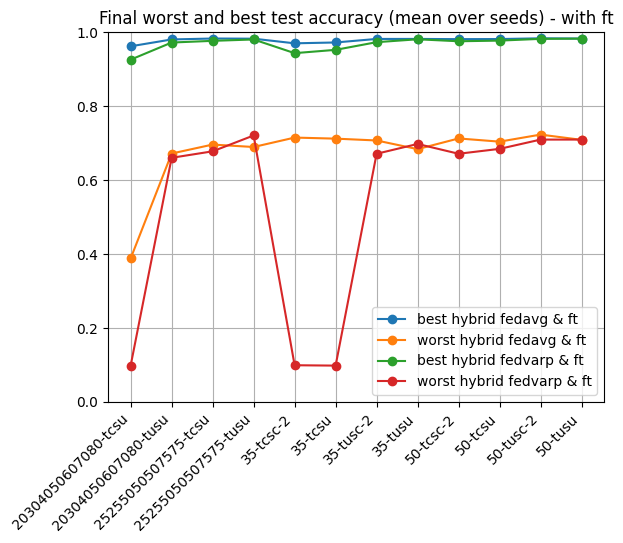

In [3]:
plot_final_best_test_acc(best_worst_res, folder, keyword)
plot_mean_seeds_var_over_training(refined_res, ["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"], folder, keyword)
plot_final_best_worst_test_acc(best_worst_res, folder, keyword)

In [4]:
best_res = refined_res.loc[refined_res.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc', 'lr']]
best_res

,algorithm,availability,final_mean_acc,lr
1,fedavg,gp-20304050607080-tcsu-10ft,0.961967,1e-2
9,fedavg,gp-20304050607080-tusu-10ft,0.980467,5e-2
10,fedavg,gp-25255050507575-tcsu-10ft,0.983000,1e-1
15,fedavg,gp-25255050507575-tusu-10ft,0.982533,1e-1
24,fedavg,gp-35-tcsc-10ft-2,0.970000,5e-2
29,fedavg,gp-35-tcsu-10ft,0.972300,5e-2
30,fedavg,gp-35-tusc-10ft-2,0.981867,1e-1
39,fedavg,gp-35-tusu-10ft,0.981900,5e-2
40,fedavg,gp-50-tcsc-10ft-2,0.981300,1e-1
45,fedavg,gp-50-tcsu-10ft,0.981567,1e-1


In [5]:
# fig, ax = plt.subplots(figsize=(6, 4))
# for av in config.availabilities:
#     df = pd.DataFrame()
#     for seed in config.seeds:
        
#         res_plot = res_tmp[res_tmp.availability == av] 
#         event_dir = config.get_event_dir(algo, lr, seed, 
#                                         event, a, n_c, av, 
#                                         config.n_rounds, part, biased, config.train_test) 
#         # print('xxx')
#         tag = res_plot[metric].values[0]
#         # print('---------->',tag)
#         # print('---------->',event_dir)
#         _, test_accuracy_values = parse_tf_events_file(event_dir, tag=tag)
#         df[seed] = test_accuracy_values
#         # print(av)
#         # yvalues = res_plot[(res_plot.availability == av)][metric]
#         # print(res_plot[(res_plot.availability == av)][metric])

#     df['mean'] = df[config.seeds].mean(axis=1)
#     df['std'] = df[config.seeds].std(axis=1)
    
#     y = df['mean']
#     y_upper = [a+b for a,b in zip(df['mean'], df['std'])]
#     y_lower = [a-b for a,b in zip(df['mean'], df['std'])]

#     # plt.errorbar(xvalues, y, df['std'], fmt='-', label = av)
#     plt.plot(xvalues, y, label= av)
#     ax.fill_between(xvalues, y_upper, y_lower, alpha=0.2)

#     # plt.plot(xvalues, test_accuracy_values, label= av)
#     ax = plt.gca()
#     ax.set_ylim([0, 1])
#     title = ('_').join([algo, a.replace("100000", "iid").replace("0.1", "non-iid"), "biased-"+biased])
#     plt.title(title)

# plt.legend(loc='lower left') 
# ax = plt.gca()
# ax.set_facecolor('#EBEBEB')
# ax.grid(which='major', color='white', linewidth=1.2)
# ax.grid(which='minor', color='white', linewidth=0.6)
# # Show the minor ticks and grid.
# ax.minorticks_on()
# # Now hide the minor ticks (but leave the gridlines).
# ax.tick_params(which='minor', bottom=False, left=False)

# plt.savefig('figures/'+folder+'/'+title+'.png', bbox_inches='tight')
# plt.show()

## Without fine-tuning

In [6]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["42", "78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["5e-2", "1e-2", "1e-3"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu gp-50-tcsu gp-35-tusu gp-50-tusu gp-35-tcsc-2 gp-35-tusc-2 gp-50-tcsc-2 gp-50-tusc-2 gp-20304050607080-tcsu gp-20304050607080-tusu gp-25255050507575-tcsu gp-25255050507575-tusu".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

folder='figures/lr_exp/quanti_analysis/without_ft'
keyword='without ft'

Processing experiments: 100%|██████████| 3/3 [00:02<00:00,  1.22it/s]


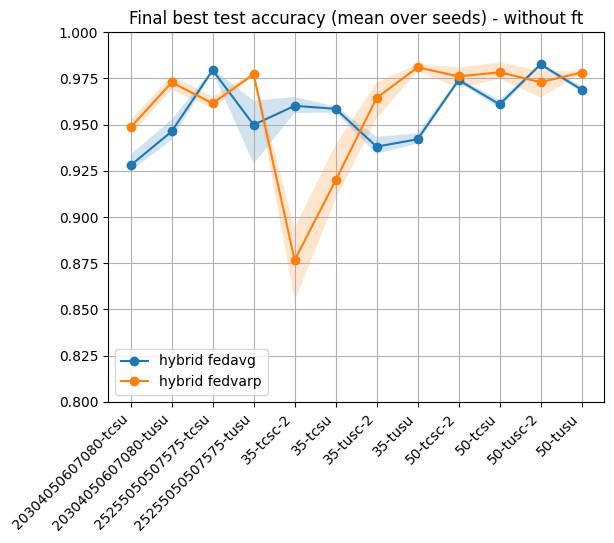

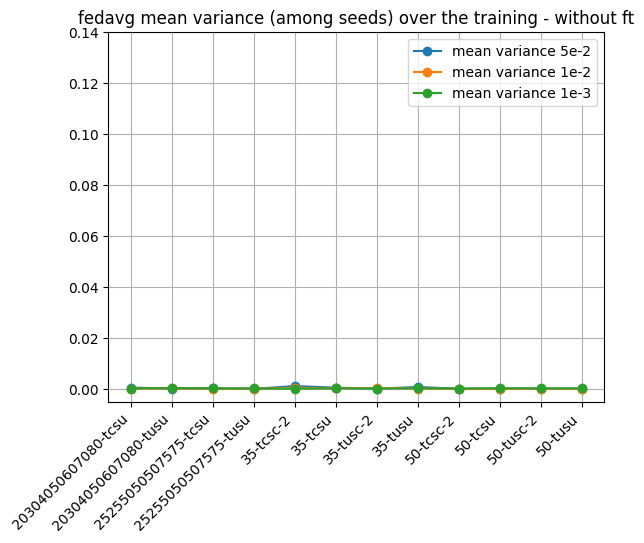

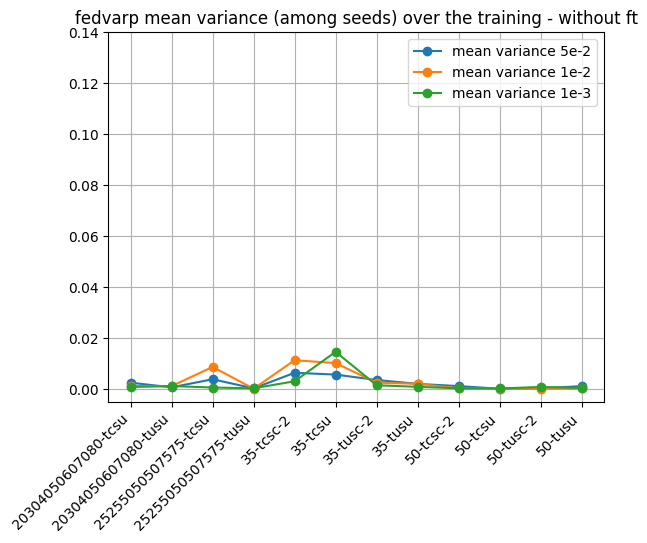

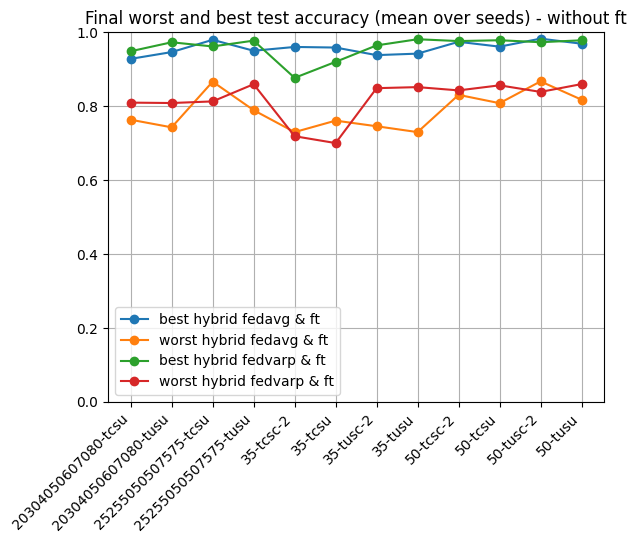

In [7]:
plot_final_best_test_acc(best_worst_res, folder, keyword)
plot_mean_seeds_var_over_training(refined_res, ["5e-2", "1e-2", "1e-3"], folder, keyword)
plot_final_best_worst_test_acc(best_worst_res, folder, keyword)

In [8]:
best_res = refined_res.loc[refined_res.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc', 'lr']]
best_res

,algorithm,availability,final_mean_acc,lr
2,fedavg,gp-20304050607080-tcsu,0.927967,5e-2
5,fedavg,gp-20304050607080-tusu,0.946300,5e-2
8,fedavg,gp-25255050507575-tcsu,0.979467,5e-2
11,fedavg,gp-25255050507575-tusu,0.949900,5e-2
14,fedavg,gp-35-tcsc-2,0.960167,5e-2
17,fedavg,gp-35-tcsu,0.958567,5e-2
20,fedavg,gp-35-tusc-2,0.938067,5e-2
23,fedavg,gp-35-tusu,0.942100,5e-2
26,fedavg,gp-50-tcsc-2,0.974100,5e-2
29,fedavg,gp-50-tcsu,0.960967,5e-2


## Effect of Batch Size

In [9]:
# gp-35-tusu-10ft MISSING AV MAT

config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["1e-2", "5e-2"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu-10ft gp-50-tcsu-10ft gp-50-tusu-10ft gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["256"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

folder='figures/lr_exp/quanti_analysis/batch_256_with_ft'
keyword = 'batch 256 with ft'

Processing experiments: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s]


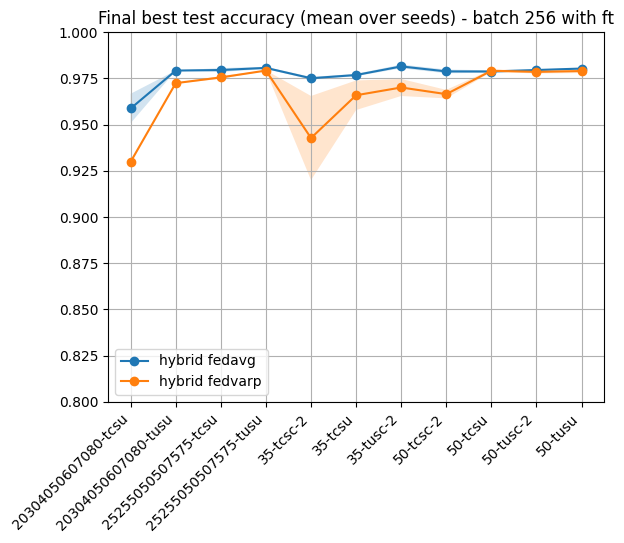

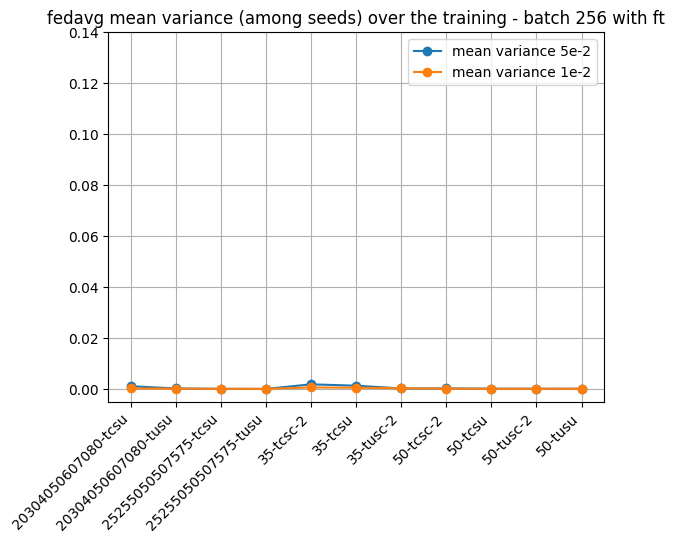

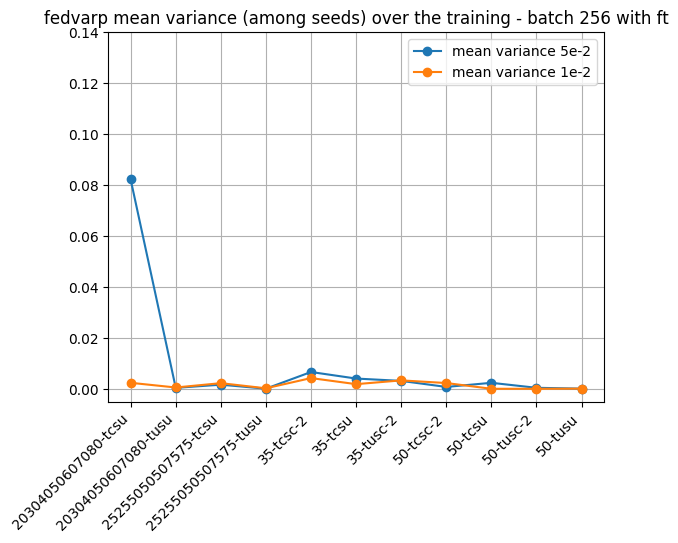

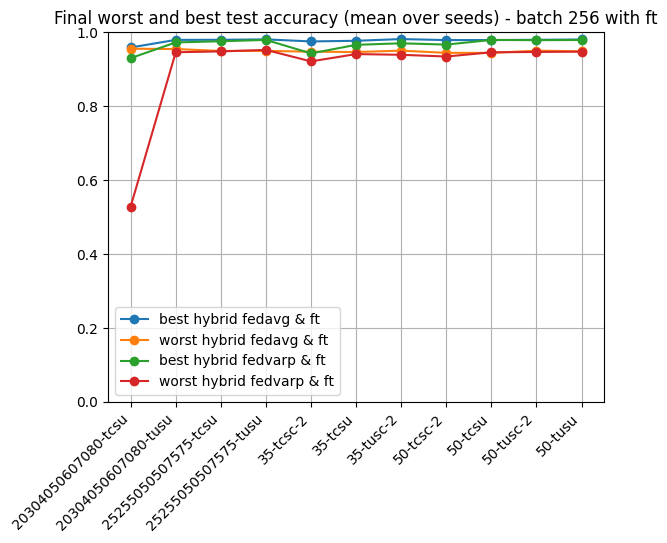

In [10]:
plot_final_best_test_acc(best_worst_res, folder, keyword)
plot_mean_seeds_var_over_training(refined_res, ["5e-2", "1e-2"], folder, keyword)
plot_final_best_worst_test_acc(best_worst_res, folder, keyword)

In [11]:
best_res = refined_res.loc[refined_res.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc', 'lr']]
best_res

,algorithm,availability,final_mean_acc,lr
1,fedavg,gp-20304050607080-tcsu-10ft,0.95875,5e-2
3,fedavg,gp-20304050607080-tusu-10ft,0.97925,5e-2
5,fedavg,gp-25255050507575-tcsu-10ft,0.97955,5e-2
7,fedavg,gp-25255050507575-tusu-10ft,0.98070,5e-2
9,fedavg,gp-35-tcsc-10ft-2,0.97510,5e-2
11,fedavg,gp-35-tcsu-10ft,0.97685,5e-2
13,fedavg,gp-35-tusc-10ft-2,0.98150,5e-2
15,fedavg,gp-50-tcsc-10ft-2,0.97880,5e-2
17,fedavg,gp-50-tcsu-10ft,0.97875,5e-2
19,fedavg,gp-50-tusc-10ft-2,0.97955,5e-2


## Av mat

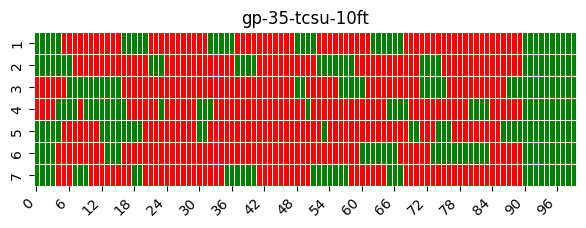

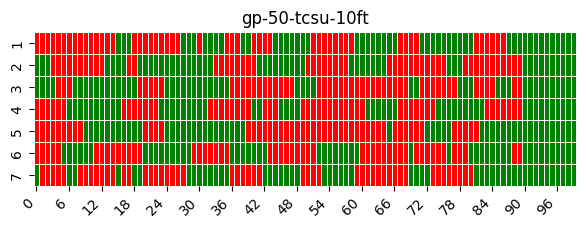

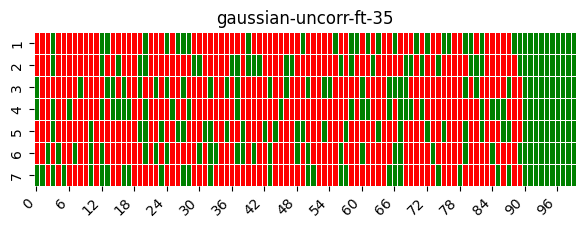

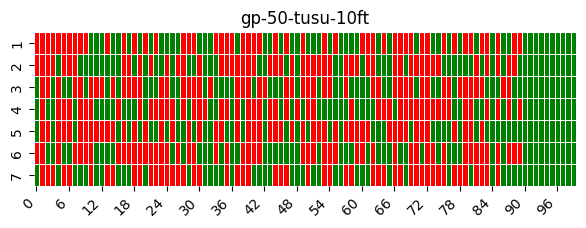

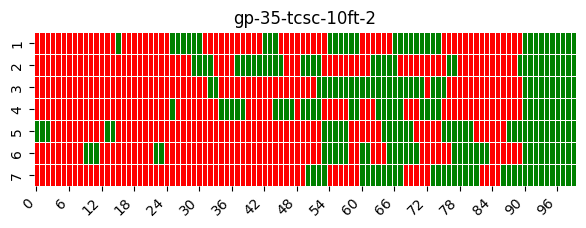

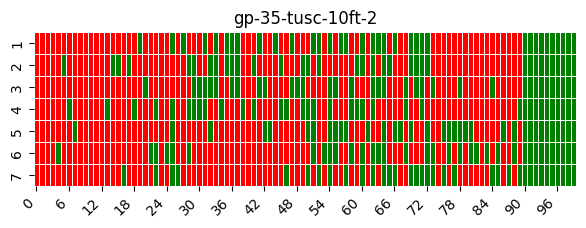

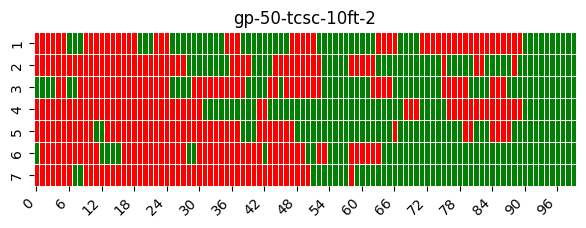

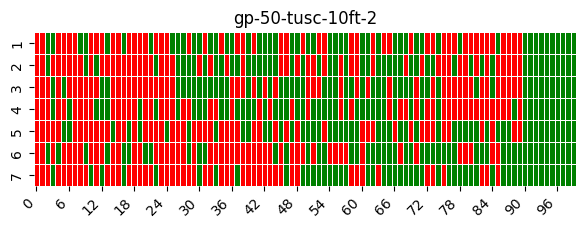

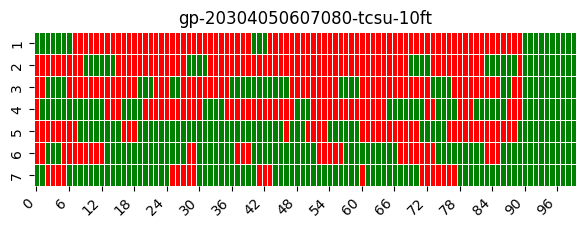

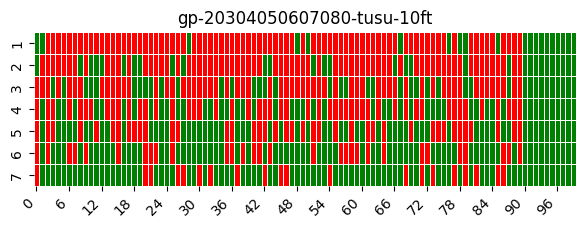

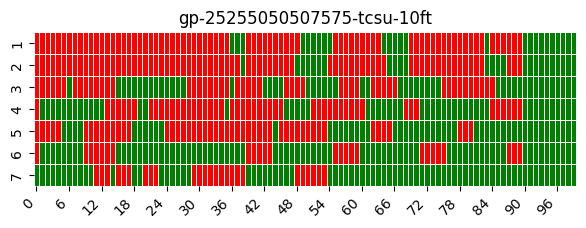

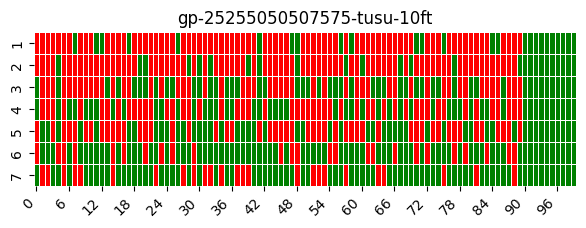

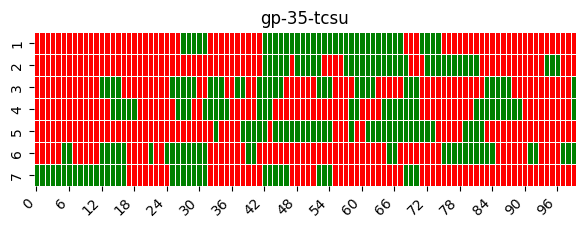

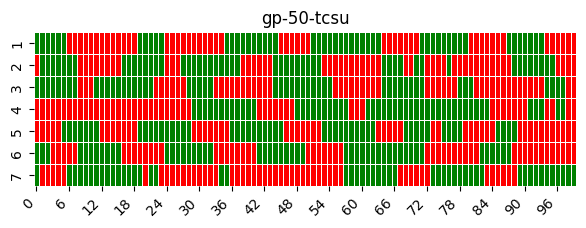

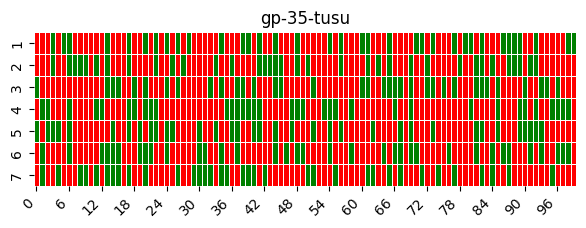

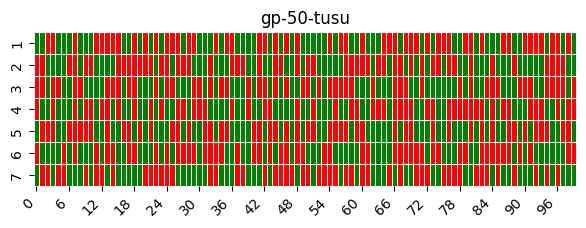

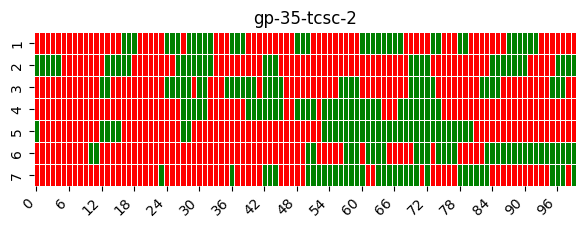

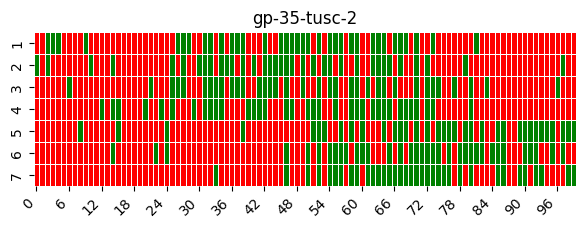

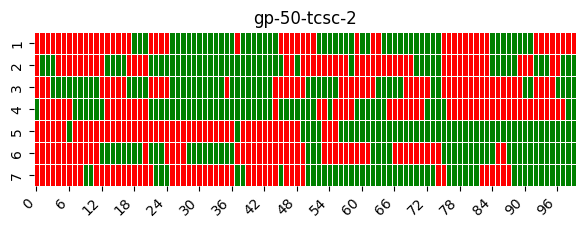

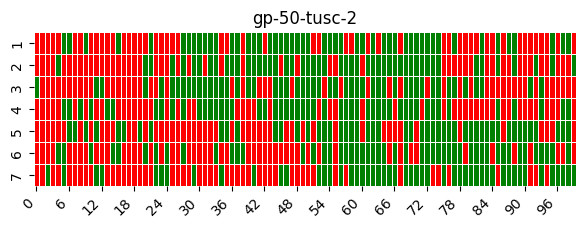

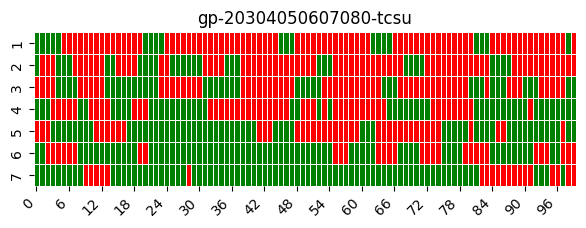

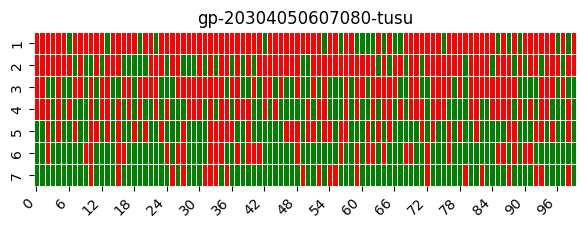

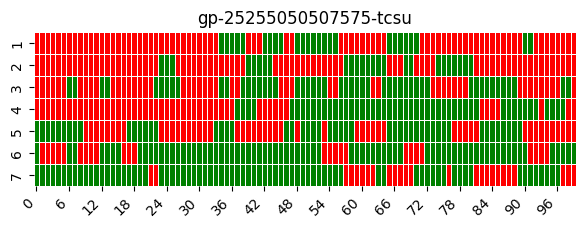

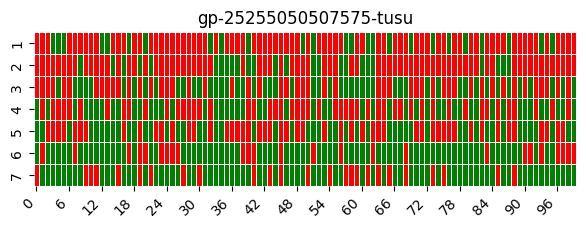

In [12]:
av_mat_list = ['gp-35-tcsu-10ft',
 'gp-50-tcsu-10ft',
#  'gp-35-tusu-10ft',
 'gaussian-uncorr-ft-35',
 'gp-50-tusu-10ft',
 'gp-35-tcsc-10ft-2',
 'gp-35-tusc-10ft-2',
 'gp-50-tcsc-10ft-2',
 'gp-50-tusc-10ft-2',
 'gp-20304050607080-tcsu-10ft',
 'gp-20304050607080-tusu-10ft',
 'gp-25255050507575-tcsu-10ft',
 'gp-25255050507575-tusu-10ft',
 'gp-35-tcsu',
 'gp-50-tcsu',
 'gp-35-tusu',
 'gp-50-tusu',
 'gp-35-tcsc-2',
 'gp-35-tusc-2',
 'gp-50-tcsc-2',
 'gp-50-tusc-2',
 'gp-20304050607080-tcsu',
 'gp-20304050607080-tusu',
 'gp-25255050507575-tcsu',
 'gp-25255050507575-tusu']
folder='lr_exp/av_mat'
for av_mat_name in av_mat_list:
    plot_av_mat(av_mat_name, folder)